In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
import os
os.chdir('/content/drive/My Drive')

In [44]:
from google.colab import files
import json, zipfile, pandas
from pandas import json_normalize

with zipfile.ZipFile("/content/drive/My Drive/device-recall-0001-of-0001.json.zip", 'r') as zip_ref:
  zip_ref.extractall('recall-data')

In [45]:
import pandas as pd
from pandas import json_normalize
import json

os.listdir('recall-data')
with open('recall-data/device-recall-0001-of-0001.json') as f:
  data = json.load(f)

df = json_normalize(data['results'])
display(df)


,cfres_id,product_res_number,event_date_initiated,event_date_posted,recall_status,res_event_number,product_code,product_description,code_info,recalling_firm,...,openfda.regulation_number,openfda.device_class,address_2,event_date_terminated,firm_fei_number,other_submission_description,k_numbers,pma_numbers,event_date_created,openfda.pma_number
0,218307,Z-1472-2026,2026-01-21,2026-02-26,"Open, Classified",98332,FNM,"Adapt Pump, Model/Catalog Number: 61600200-Ada...",UDI-DI 0084569904914; All serial numbers with ...,Agiliti Health Ellis,...,880.5550,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,218406,Z-1462-2026,2026-01-14,2026-02-24,"Open, Classified",98303,KPL,"PIE PAK\nModels: P2HC-A, P2HC-S, P2HC",All Lots\nUDI:,Edermy LLC,...,876.5220,2,Ste A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,105069,Z-0389-2012,2011-09-19,2012-01-11,Terminated,60344,LFQO,Magnus Hybrid operating table columns 1180.01A...,"510 k EXEMPT 1180.01A1- Lot #0002, 0004, 0005...",Maquet Inc.,...,NaN,NaN,NaN,2011-12-08,NaN,NaN,NaN,NaN,NaN,NaN
3,105700,Z-0485-2012,2011-11-28,2012-01-11,Terminated,60528,RER,Raymond Laser alignment guide - Model #1096597...,Model #1096597/002,The Raymond Corporation S Canal,...,,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,131624,Z-0604-2015,2014-11-17,2014-12-12,Terminated,69838,KOG,"PKG, OBTURATOR, 5.5MM FOR HASSON CANNULA, P/N ...",37302 37858 39543 45622 48347 48903 49147 4914...,Stryker Endoscopy,...,NaN,NaN,NaN,2015-07-17,2936485,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57506,217626,Z-1062-2026,2025-12-15,2026-01-13,"Open, Classified",98109,OWB,Product Name: Allura Xper FD10C;\nModel number...,Model Number: 722001;\nSystem Product Name: Al...,PHILIPS MEDICAL SYSTEMS NEDERLAND B.V. Veenplu...,...,892.1650,2,NaN,NaN,NaN,NaN,"[K102005, K130638, K130842, K133292, K141979, ...",NaN,NaN,NaN
57507,217850,Z-1096-2026,2025-12-15,2026-01-15,"Open, Classified",98187,NAY,"da Vinci SP, SP Access Port Kit, Large Incisi...",REF: 430073\nUDI: 00886874119549\nLot Numbers...,"Intuitive Surgical, Inc.",...,876.1500,2,NaN,NaN,NaN,NaN,[K202571],NaN,NaN,NaN
57508,217742,Z-1059-2026,2025-11-26,2026-01-12,"Open, Classified",98154,OJG,Medline Kits containing B. Braun IV Administra...,UDI/DI 10884389725092 (EA) 40884389725093 (CS)...,NaN,...,882.4525,1,"Medline Industries, LP",NaN,NaN,NaN,NaN,NaN,NaN,NaN
57509,217876,Z-1086-2026,2025-12-16,2026-01-14,"Open, Classified",98197,FDE,Medline medical procedure convenience kits lab...,REF CDS860235L: UDI/DI 10198459258664 (EA)401...,NaN,...,876.1500,2,"Medline Industries, LP",NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data description: The data table gives the ID, description, and product code as well as the recall date and status.


In [46]:
unique_products = df['cfres_id'].nunique()
print(unique_products)

57503


In [47]:
df['cfres_id'].value_counts().idxmax()

'217732'

In [48]:
df.columns

Index(['cfres_id', 'product_res_number', 'event_date_initiated',
       'event_date_posted', 'recall_status', 'res_event_number',
       'product_code', 'product_description', 'code_info', 'recalling_firm',
       'address_1', 'city', 'state', 'postal_code', 'additional_info_contact',
       'reason_for_recall', 'root_cause_description', 'action',
       'product_quantity', 'distribution_pattern', 'openfda.k_number',
       'openfda.registration_number', 'openfda.fei_number',
       'openfda.device_name', 'openfda.medical_specialty_description',
       'openfda.regulation_number', 'openfda.device_class', 'address_2',
       'event_date_terminated', 'firm_fei_number',
       'other_submission_description', 'k_numbers', 'pma_numbers',
       'event_date_created', 'openfda.pma_number'],
      dtype='object')

In [49]:
df['reason_for_recall']

,reason_for_recall
0,Agiliti identified an issue where the Adapt Pu...
1,Lack of 510K clearance
2,A component of the Magnus hybrid OR system fai...
3,Raymond shipped a laser alignment guide as an ...
4,The parameters provided in the Laparoscopic Ma...
...,...
57506,Philips has identified that in a limited numbe...
57507,Access Port System tray may develop cracks po...
57508,Medline kits contain B. Braun IV Administratio...
57509,Medline kits containing Stryker's Strykeflow 2...


In [50]:
# Drop any values that have a null CFRES ID

df.dropna(subset=['cfres_id'])


,cfres_id,product_res_number,event_date_initiated,event_date_posted,recall_status,res_event_number,product_code,product_description,code_info,recalling_firm,...,openfda.regulation_number,openfda.device_class,address_2,event_date_terminated,firm_fei_number,other_submission_description,k_numbers,pma_numbers,event_date_created,openfda.pma_number
0,218307,Z-1472-2026,2026-01-21,2026-02-26,"Open, Classified",98332,FNM,"Adapt Pump, Model/Catalog Number: 61600200-Ada...",UDI-DI 0084569904914; All serial numbers with ...,Agiliti Health Ellis,...,880.5550,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,218406,Z-1462-2026,2026-01-14,2026-02-24,"Open, Classified",98303,KPL,"PIE PAK\nModels: P2HC-A, P2HC-S, P2HC",All Lots\nUDI:,Edermy LLC,...,876.5220,2,Ste A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,105069,Z-0389-2012,2011-09-19,2012-01-11,Terminated,60344,LFQO,Magnus Hybrid operating table columns 1180.01A...,"510 k EXEMPT 1180.01A1- Lot #0002, 0004, 0005...",Maquet Inc.,...,NaN,NaN,NaN,2011-12-08,NaN,NaN,NaN,NaN,NaN,NaN
3,105700,Z-0485-2012,2011-11-28,2012-01-11,Terminated,60528,RER,Raymond Laser alignment guide - Model #1096597...,Model #1096597/002,The Raymond Corporation S Canal,...,,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,131624,Z-0604-2015,2014-11-17,2014-12-12,Terminated,69838,KOG,"PKG, OBTURATOR, 5.5MM FOR HASSON CANNULA, P/N ...",37302 37858 39543 45622 48347 48903 49147 4914...,Stryker Endoscopy,...,NaN,NaN,NaN,2015-07-17,2936485,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57506,217626,Z-1062-2026,2025-12-15,2026-01-13,"Open, Classified",98109,OWB,Product Name: Allura Xper FD10C;\nModel number...,Model Number: 722001;\nSystem Product Name: Al...,PHILIPS MEDICAL SYSTEMS NEDERLAND B.V. Veenplu...,...,892.1650,2,NaN,NaN,NaN,NaN,"[K102005, K130638, K130842, K133292, K141979, ...",NaN,NaN,NaN
57507,217850,Z-1096-2026,2025-12-15,2026-01-15,"Open, Classified",98187,NAY,"da Vinci SP, SP Access Port Kit, Large Incisi...",REF: 430073\nUDI: 00886874119549\nLot Numbers...,"Intuitive Surgical, Inc.",...,876.1500,2,NaN,NaN,NaN,NaN,[K202571],NaN,NaN,NaN
57508,217742,Z-1059-2026,2025-11-26,2026-01-12,"Open, Classified",98154,OJG,Medline Kits containing B. Braun IV Administra...,UDI/DI 10884389725092 (EA) 40884389725093 (CS)...,NaN,...,882.4525,1,"Medline Industries, LP",NaN,NaN,NaN,NaN,NaN,NaN,NaN
57509,217876,Z-1086-2026,2025-12-16,2026-01-14,"Open, Classified",98197,FDE,Medline medical procedure convenience kits lab...,REF CDS860235L: UDI/DI 10198459258664 (EA)401...,NaN,...,876.1500,2,"Medline Industries, LP",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
# Drop any recall tickets initiated before 2015 or after 2025.

df = df.copy()

df['event_date_initiated'] = pd.to_datetime(df['event_date_initiated'], errors='coerce')
df = df[(df['event_date_initiated'] >= '2015-01-01') & (df['event_date_initiated'] <= '2025-12-31')]

In [52]:
df

,cfres_id,product_res_number,event_date_initiated,event_date_posted,recall_status,res_event_number,product_code,product_description,code_info,recalling_firm,...,openfda.regulation_number,openfda.device_class,address_2,event_date_terminated,firm_fei_number,other_submission_description,k_numbers,pma_numbers,event_date_created,openfda.pma_number
26,214301,Z-1942-2025,2025-05-13,2025-06-18,"Open, Classified",97035,RCE,Ami HTX.,Accession number 2510780-000,Spectral Instruments Inc,...,,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,208478,Z-2166-2024,2024-03-28,2024-07-01,"Open, Classified",94839,REM,HORIBA custom configured fluorescence instrume...,Modular Fluorolog-QM,Horiba Instruments Incorporated,...,,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,196079,Z-0003-2023,2022-01-27,2022-10-05,"Open, Classified",90860,RHP,The product is a handheld ultraviolet-C germic...,Model Seago SG-153,IN MY BATHROOM LLC,...,,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,155043,Z-2344-2017,2017-04-20,2017-05-22,Terminated,77026,N/A,"VITEK 2 Bacillus identification card (BCL), I...",2390150203 25/Apr/18,Biomerieux Inc,...,NaN,NaN,NaN,2020-07-22,1950204,NaN,NaN,NaN,NaN,NaN
58,173299,Z-1784-2019,2019-01-29,NaN,"Open, Classified",82988,RET,TASE 500 Imaging systems,TASE 500,COLLINS AEROSPACE,...,,N,NaN,NaN,3015196094,RadHealth Certified,NaN,NaN,2019-06-28,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57506,217626,Z-1062-2026,2025-12-15,2026-01-13,"Open, Classified",98109,OWB,Product Name: Allura Xper FD10C;\nModel number...,Model Number: 722001;\nSystem Product Name: Al...,PHILIPS MEDICAL SYSTEMS NEDERLAND B.V. Veenplu...,...,892.1650,2,NaN,NaN,NaN,NaN,"[K102005, K130638, K130842, K133292, K141979, ...",NaN,NaN,NaN
57507,217850,Z-1096-2026,2025-12-15,2026-01-15,"Open, Classified",98187,NAY,"da Vinci SP, SP Access Port Kit, Large Incisi...",REF: 430073\nUDI: 00886874119549\nLot Numbers...,"Intuitive Surgical, Inc.",...,876.1500,2,NaN,NaN,NaN,NaN,[K202571],NaN,NaN,NaN
57508,217742,Z-1059-2026,2025-11-26,2026-01-12,"Open, Classified",98154,OJG,Medline Kits containing B. Braun IV Administra...,UDI/DI 10884389725092 (EA) 40884389725093 (CS)...,NaN,...,882.4525,1,"Medline Industries, LP",NaN,NaN,NaN,NaN,NaN,NaN,NaN
57509,217876,Z-1086-2026,2025-12-16,2026-01-14,"Open, Classified",98197,FDE,Medline medical procedure convenience kits lab...,REF CDS860235L: UDI/DI 10198459258664 (EA)401...,NaN,...,876.1500,2,"Medline Industries, LP",NaN,NaN,NaN,NaN,NaN,NaN,NaN


Exploratory data analysis


In [53]:
#Columns with no NaNs

df_no_nan = df[df.columns[~df.isnull().any()]]
df_no_nan

,cfres_id,product_res_number,event_date_initiated,recall_status,res_event_number,product_description,code_info,distribution_pattern
26,214301,Z-1942-2025,2025-05-13,"Open, Classified",97035,Ami HTX.,Accession number 2510780-000,US
27,208478,Z-2166-2024,2024-03-28,"Open, Classified",94839,HORIBA custom configured fluorescence instrume...,Modular Fluorolog-QM,US Nationwide and Worldwide Distribution
28,196079,Z-0003-2023,2022-01-27,"Open, Classified",90860,The product is a handheld ultraviolet-C germic...,Model Seago SG-153,US Nationwide Distribution
57,155043,Z-2344-2017,2017-04-20,Terminated,77026,"VITEK 2 Bacillus identification card (BCL), I...",2390150203 25/Apr/18,"Nationwide distribution in the U.S, including ..."
58,173299,Z-1784-2019,2019-01-29,"Open, Classified",82988,TASE 500 Imaging systems,TASE 500,US Nationwide Distribution
...,...,...,...,...,...,...,...,...
57506,217626,Z-1062-2026,2025-12-15,"Open, Classified",98109,Product Name: Allura Xper FD10C;\nModel number...,Model Number: 722001;\nSystem Product Name: Al...,Worldwide distribution - US Nationwide and the...
57507,217850,Z-1096-2026,2025-12-15,"Open, Classified",98187,"da Vinci SP, SP Access Port Kit, Large Incisi...",REF: 430073\nUDI: 00886874119549\nLot Numbers...,Worldwide - US Nationwide distribution includi...
57508,217742,Z-1059-2026,2025-11-26,"Open, Classified",98154,Medline Kits containing B. Braun IV Administra...,UDI/DI 10884389725092 (EA) 40884389725093 (CS)...,US Nationwide distribution.
57509,217876,Z-1086-2026,2025-12-16,"Open, Classified",98197,Medline medical procedure convenience kits lab...,REF CDS860235L: UDI/DI 10198459258664 (EA)401...,US Nationwide distribution.


/tmp/ipykernel_647/2636557825.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recall Status', y='Count', data=recall_status_counts, palette='viridis')


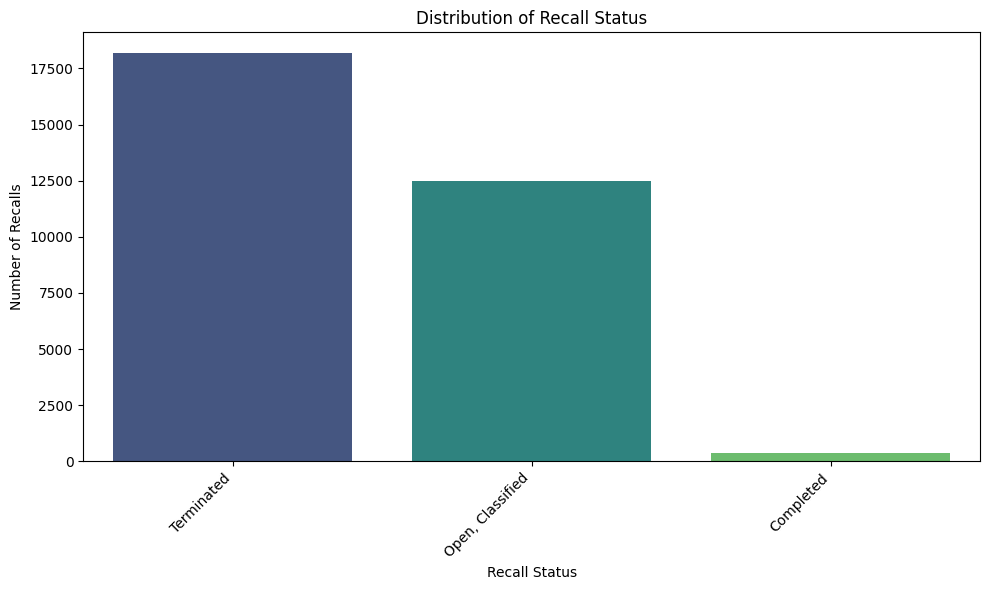

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph of recall status of each
recall_status_counts = df_no_nan['recall_status'].value_counts().reset_index()
recall_status_counts.columns = ['Recall Status', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Recall Status', y='Count', data=recall_status_counts, palette='viridis')
plt.title('Distribution of Recall Status')
plt.xlabel('Recall Status')
plt.ylabel('Number of Recalls')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [55]:
post_pan = df.copy()

post_pan['event_date_initiated'] = pd.to_datetime(post_pan['event_date_initiated'], errors='coerce')
post_pan = post_pan[(post_pan['event_date_initiated'] >= '2022-01-01') & (post_pan['event_date_initiated'] <= '2024-12-31')]
display(post_pan['root_cause_description'])
grouped = post_pan['root_cause_description'].value_counts().reset_index()
grouped.columns = ['Root Cause Description', 'Count']
display(grouped)

,root_cause_description
27,Radiation Control for Health and Safety Act
28,Radiation Control for Health and Safety Act
61,Radiation Control for Health and Safety Act
92,Radiation Control for Health and Safety Act
115,Radiation Control for Health and Safety Act
...,...
57338,Labeling Change Control
57370,Software design
57371,Software design
57488,Software Design Change


,Root Cause Description,Count
0,Under Investigation by firm,2366
1,Process control,1238
2,Device Design,784
3,Nonconforming Material/Component,780
4,No Marketing Application,353
5,Software design,312
6,Process change control,221
7,Other,189
8,Process design,145
9,Component design/selection,145


/tmp/ipykernel_647/2431054128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Root Cause Description', y='Count', data=grouped, palette='viridis')


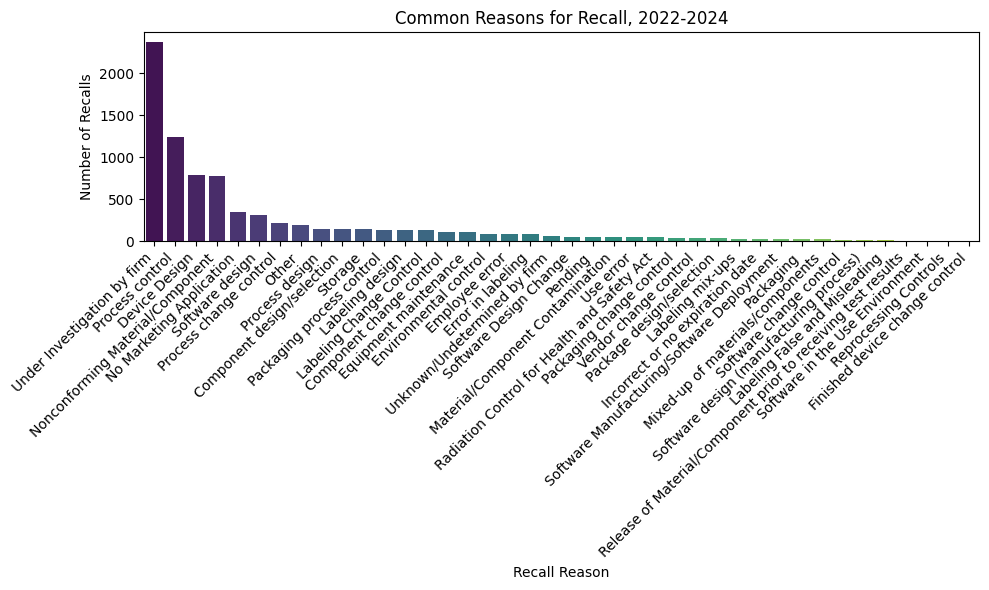

In [56]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Root Cause Description', y='Count', data=grouped, palette='viridis')
plt.title('Common Reasons for Recall, 2022-2024')
plt.xlabel('Recall Reason')
plt.ylabel('Number of Recalls')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_647/1838141287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recall Status', y='Count', data=recall_status_counts_24, palette='viridis')


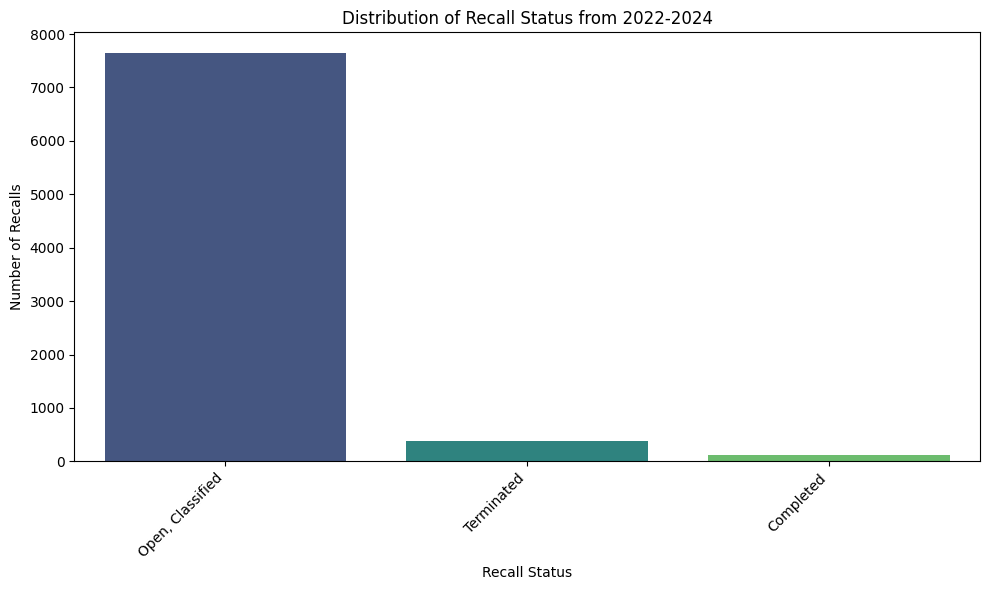

In [57]:
recall_status_counts_24 = post_pan['recall_status'].value_counts().reset_index()
recall_status_counts_24.columns = ['Recall Status', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Recall Status', y='Count', data=recall_status_counts_24, palette='viridis')
plt.title('Distribution of Recall Status from 2022-2024')
plt.xlabel('Recall Status')
plt.ylabel('Number of Recalls')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [58]:
file_path = "output/cleaned_recall_data.csv"

try:
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    df.to_csv(
        file_path,
        index=False,
        encoding="utf-8",
        na_rep="N/A"
    )

    print(f"DataFrame successfully exported to {file_path}")

except (OSError, IOError) as e:
    print(f"Error saving CSV file: {e}")

DataFrame successfully exported to output/cleaned_recall_data.csv
